In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn tools
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

# Load data
df = pd.read_csv(r"C:\Users\MRUGANK KAPSE\Downloads\Iris.csv")

# Basic cleaning
df = df.drop_duplicates()
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

df.head()
print(df)

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
0              5.1           3.5            1.4           0.2     Iris-setosa
1              4.9           3.0            1.4           0.2     Iris-setosa
2              4.7           3.2            1.3           0.2     Iris-setosa
3              4.6           3.1            1.5           0.2     Iris-setosa
4              5.0           3.6            1.4           0.2     Iris-setosa
..             ...           ...            ...           ...             ...
145            6.7           3.0            5.2           2.3  Iris-virginica
146            6.3           2.5            5.0           1.9  Iris-virginica
147            6.5           3.0            5.2           2.0  Iris-virginica
148            6.2           3.4            5.4           2.3  Iris-virginica
149            5.9           3.0            5.1           1.8  Iris-virginica

[150 rows x 5 columns]


In [8]:
print(df.head(10))
print(df.tail(10))
print(df.describe())
print(df)
print(df.info())
print(df.shape)
print(df.isnull().sum())

df = df.drop_duplicates()
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

df['SepalArea'] = df['SepalLengthCm'] * df['SepalWidthCm']
df['PetalArea'] = df['PetalLengthCm'] * df['PetalWidthCm']

sepal_length = df['SepalLengthCm'].to_numpy()
petal_length = df['PetalLengthCm'].to_numpy()

print(np.mean(sepal_length))
print(np.std(petal_length))
print(np.max(sepal_length))
print(np.min(petal_length))

df['SepalSize'] = np.where(
    df['SepalArea'] > df['SepalArea'].mean(),
    'Large',
    'Small'
)

print(df.groupby('Species').mean(numeric_only=True))

print(
    df.groupby('Species').agg({
        'SepalLengthCm': ['mean', 'min', 'max'],
        'PetalLengthCm': ['mean', 'std']
    })
)

df_sorted = df.sort_values(by='PetalLengthCm', ascending=False)
print(df_sorted.head())

df['SepalLengthNorm'] = (
    (df['SepalLengthCm'] - df['SepalLengthCm'].min()) /
    (df['SepalLengthCm'].max() - df['SepalLengthCm'].min())
)

large_sepal = df[df['SepalArea'] > df['SepalArea'].mean()]
print(large_sepal.head())

sample = df.sample(10, random_state=1)
print(sample)

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa
5            5.4           3.9            1.7           0.4  Iris-setosa
6            4.6           3.4            1.4           0.3  Iris-setosa
7            5.0           3.4            1.5           0.2  Iris-setosa
8            4.4           2.9            1.4           0.2  Iris-setosa
9            4.9           3.1            1.5           0.1  Iris-setosa
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
140            6.7           3.1            5.6           2.4  Iris-virginica
141            6.9           3.1         

In [3]:
# Feature Engineering
df['SepalArea'] = df['SepalLengthCm'] * df['SepalWidthCm']
df['PetalArea'] = df['PetalLengthCm'] * df['PetalWidthCm']

# Define Features and Target
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

# Initialize and Apply MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Scaled Features (First 5 rows):")
print(X_scaled_df.head())

Scaled Features (First 5 rows):
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0       0.222222      0.625000       0.067797      0.041667
1       0.166667      0.416667       0.067797      0.041667
2       0.111111      0.500000       0.050847      0.041667
3       0.083333      0.458333       0.084746      0.041667
4       0.194444      0.666667       0.067797      0.041667


In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
knn = KNeighborsClassifier(n_neighbors=3)

# Evaluate using cross_val_score
kf_scores = cross_val_score(knn, X_scaled, y, cv=kf)

print(f"K-Fold Scores: {kf_scores}")
print(f"Mean Accuracy: {kf_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {kf_scores.std():.4f}")

K-Fold Scores: [1.         0.96666667 0.93333333 0.93333333 0.9       ]
Mean Accuracy: 94.67%
Standard Deviation: 0.0340


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

skf_scores = cross_val_score(knn, X_scaled, y, cv=skf)

print(f"Stratified K-Fold Scores: {skf_scores}")
print(f"Mean Accuracy: {skf_scores.mean() * 100:.2f}%")

Stratified K-Fold Scores: [0.96666667 1.         0.93333333 0.96666667 0.9       ]
Mean Accuracy: 95.33%


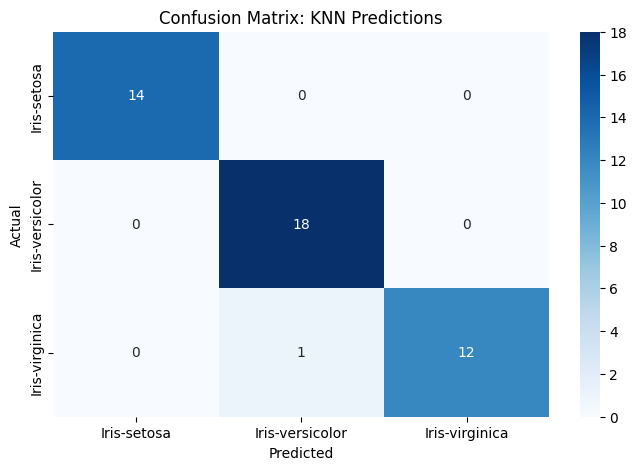

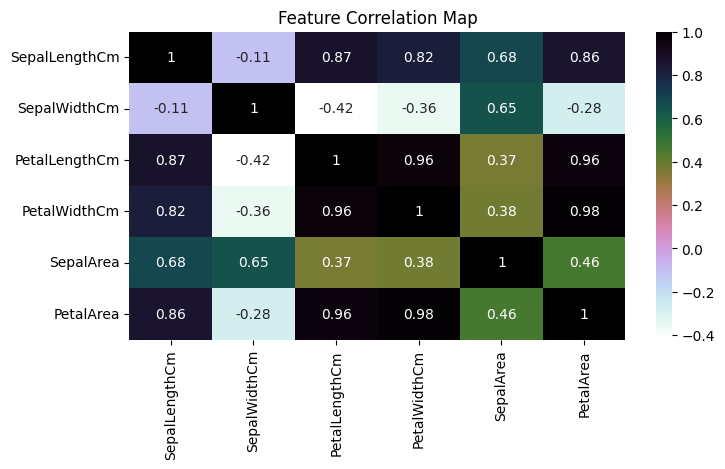

In [6]:
# Split scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=1)

# Fit and Predict
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 5))
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=df['Species'].unique(), 
            yticklabels=df['Species'].unique())
plt.title("Confusion Matrix: KNN Predictions")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Correlation Heatmap for original numeric features
plt.figure(figsize=(8, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='cubehelix_r')
plt.title("Feature Correlation Map")
plt.show()